# Sine wave prediction using LSTM

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from helper_functions import create_sequences, forecast_with_model
from models import LSTM

np.random.seed(0)
torch.manual_seed(0)

In [2]:
# Simple
# t = np.linspace(0, 100, 1000)
# data = np.sin(t)
# seq_length = 10

# Matching climate data
amp = 1
freq = 1/365  # where 365 is the period of the data
phase = 0
max_time = 1575
num_timesteps = max_time  # one data point per day
seq_length = 200

t = np.linspace(0, max_time, num_timesteps)
data = amp*np.sin(2*(np.pi)*freq*t + phase)

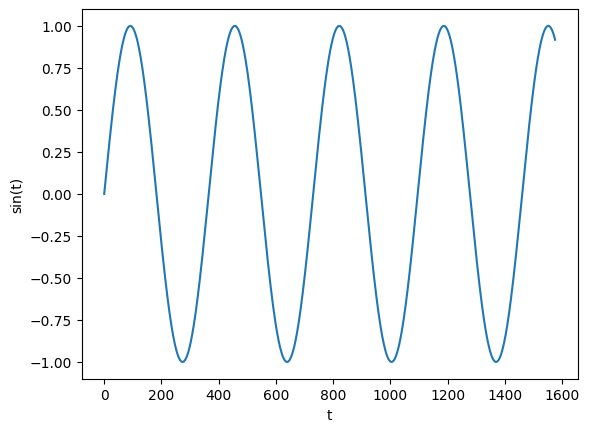

In [ ]:
train = data[:int(len(data)*0.8)]
train_t = t[:int(len(data)*0.8)]
test = data[int(len(data)*0.8):]
test_t = t[int(len(data)*0.8):]

plt.plot(t, data)
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.show()

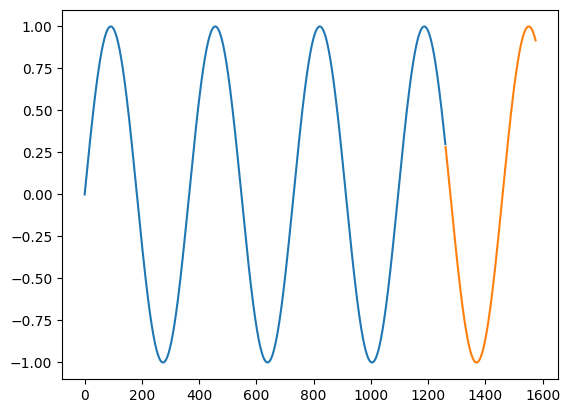

In [4]:
plt.plot(train_t, train, label="Training data")
plt.plot(test_t, test, label="Test data")
plt.show()

In [ ]:
X_train, y_train = create_sequences(train, seq_length)
X_test, y_test = create_sequences(test, seq_length)

X_train = torch.tensor(X_train[:, :, None], dtype=torch.float32)
y_train = torch.tensor(y_train[:, None], dtype=torch.float32)
X_test = torch.tensor(X_test[:, :, None], dtype=torch.float32)
y_test = torch.tensor(y_test[:, None], dtype=torch.float32)

In [5]:
model = LSTM(input_size=1, hidden_size=100, num_layers=1, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [18]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train.reshape(-1,1))
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.2461
Epoch [20/100], Loss: 0.0181
Epoch [30/100], Loss: 0.0078
Epoch [40/100], Loss: 0.0040
Epoch [50/100], Loss: 0.0023
Epoch [60/100], Loss: 0.0012
Epoch [70/100], Loss: 0.0008
Epoch [80/100], Loss: 0.0007
Epoch [90/100], Loss: 0.0005
Epoch [100/100], Loss: 0.0005


In [19]:
colours = {
    "Ground truth": "#1589e8",
    "LSTM": "#dc267f",
    "Starting data": "#631ff3"
}

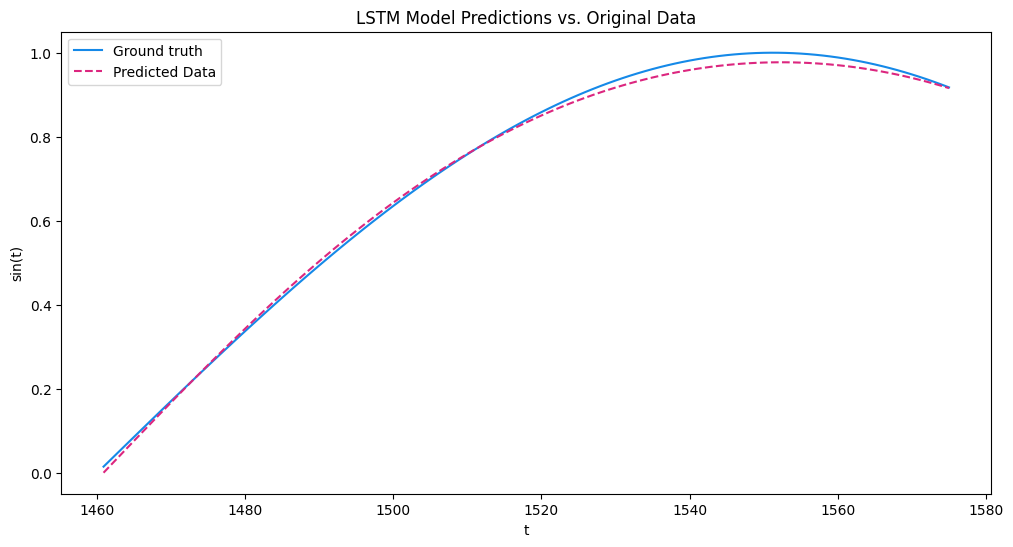

In [20]:
model.eval()
predicted = model(X_test)

original = test[seq_length:]
time_steps = test_t[seq_length:]

plt.figure(figsize=(12, 6))
plt.plot(time_steps, original, label='Ground truth', c=colours["Ground truth"])
plt.plot(time_steps, predicted.detach().numpy(),
         label='Predicted Data', linestyle='--', c=colours["LSTM"])
plt.title('LSTM Model Predictions vs. Original Data')
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.legend()
plt.show()

In [21]:
start_data = X_test[0:1]

y_forecast = forecast_with_model(model=model, start_data=start_data, forecast_length=len(test)-seq_length)

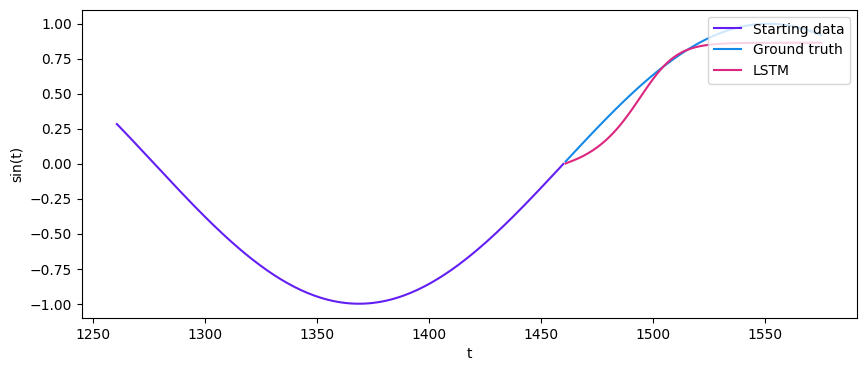

In [22]:
time_steps = test_t[seq_length:] # test set minus first sequence
plt.figure(figsize=(10, 4))
plt.plot(test_t[:seq_length], start_data.squeeze(), label='Starting data', c=colours['Starting data'])
plt.plot(time_steps, test[seq_length:], label='Ground truth', c=colours['Ground truth'])
plt.plot(time_steps, y_forecast, label='LSTM', c=colours['LSTM'])
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.legend(loc='upper right')